<br/>

<div align="center">
<span style="font-size: 2.5em;">Jensen-Shannon Divergence Analysis</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Comparing learned neural network posteriors with analytical reference distributions</span>
</div>

## Overview

The **Jensen–Shannon divergence** (JSD) is a symmetric, finite measure of dissimilarity between two probability distributions. It is ideal for comparing learned neural network posteriors with analytical or reference distributions in a mathematically principled way.

### Key Advantages

- **Symmetric**: $\mathrm{JSD}(P, Q) = \mathrm{JSD}(Q, P)$
- **Finite and well-defined** even when distributions have disjoint support
- **Bounded**: $0 \le \mathrm{JSD}(P, Q) \le \log 2$ (often normalized to $[0, 1]$)
- **True metric**: $\sqrt{\mathrm{JSD}}$ defines a proper metric on probability distributions

## Mathematical Definition

Given two discrete probability distributions $P$ and $Q$:

$$
\mathrm{JSD}(P, Q)
=
\frac{1}{2}\,\mathrm{KL}(P \,\|\, M)
+
\frac{1}{2}\,\mathrm{KL}(Q \,\|\, M),
\qquad
M = \frac{1}{2}(P + Q)
$$

where the Kullback–Leibler divergence is:

$$
\mathrm{KL}(P \,\|\, Q)
=
\sum_i P_i \log \frac{P_i}{Q_i}
$$

## Interpretation

- $\mathrm{JSD} = 0$ → distributions are identical
- Larger values → increasing dissimilarity
- Sensitive to both distribution **shape** and **support**
- Useful for model validation and posterior calibration assessment

In [1]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os, sys
desired_root_name = "dark-matter-sbi"  
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch

from data.mc_generator import mc_generator
from configs.config import load_model, PARAM_RANGES
from utils.processing import load_matching_pairs
from analytical.ppg_class import PoissonPosteriorGrid
from performances.metrics import jsd_eval, plot_jsd_diagnostics

## Model Configuration

Specify the model architecture, halo assumption, and data parameters for evaluation.

In [2]:
# ===========================================
# PARAMETERS TO DEFINE THE DATA AND MODEL 
# ===========================================

modelname = "ntothighest"          
halo      = "default"       
datatag   = "low"
n_train   = 300_000
top_k     = 10              

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Data and Model Loading

Load the trained model and prepare dataloaders for evaluation.

In [3]:
# =============================
# LOAD MODEL AND CHECKPOINT
# =============================

DATAPATH = f"data/datasets/wimpy/{halo}/wimpy_n{n_train}_{datatag}_{halo}.pt"
MODELPATH = f"models/wimpy/{halo}/{modelname}_n{n_train}_{datatag}_{halo}.pt"

model, ckpt = load_model(MODELPATH, modelname, print_arch=False)
print(f"Loading model from:\n{MODELPATH}\n")

Loading model from:
models/wimpy/default/ntothighest_n300000_low_default.pt



In [4]:
# =====================================
# LOAD TEST AND/OR VALIDATION DATA
# =====================================

X_val, T_val = load_matching_pairs(halo_choice=halo, n_train=n_train, datatag=datatag, split="val")

Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt



## JSD Evaluation

Compute Jensen-Shannon divergence between learned neural network posteriors (from validation data) and analytical reference posteriors across the parameter space.

In [8]:
resolution = 100 

ppg = PoissonPosteriorGrid.load_or_compute(datatag, resolution, mc_generator)

mean_jsd, results = jsd_eval(
    model=model, test_features=X_val, test_thetas=T_val, logm_range=logm_range, logcp_range=logcp_range, ppg=ppg, posteriorbins=resolution, n_samples=2000
)

Mean JSD: 0.02257042649976946


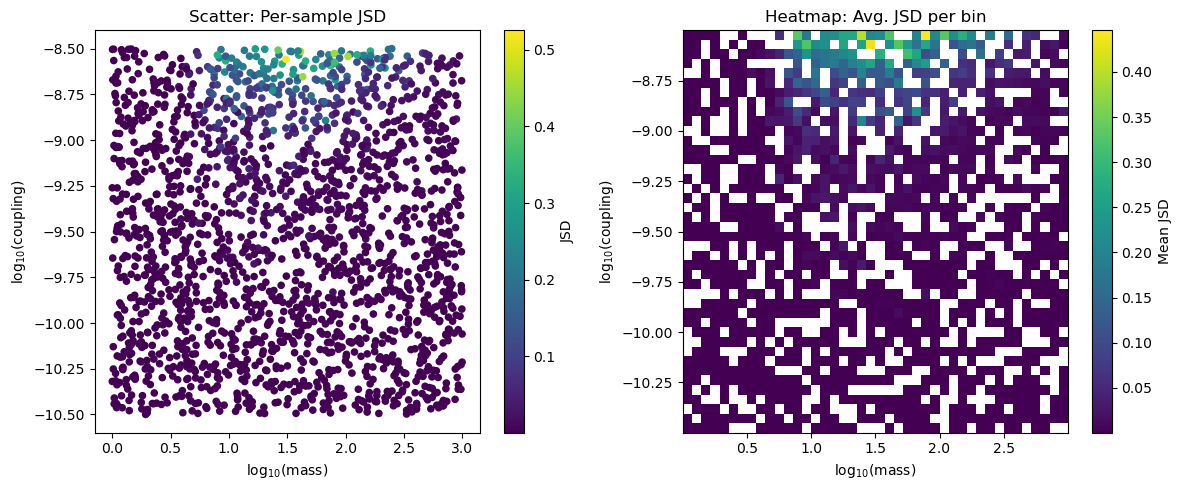

In [16]:
print("Mean JSD:", mean_jsd)
plot_jsd_diagnostics(results, bins=42, fill_holes=False)

Mean JSD: 0.02257042649976946


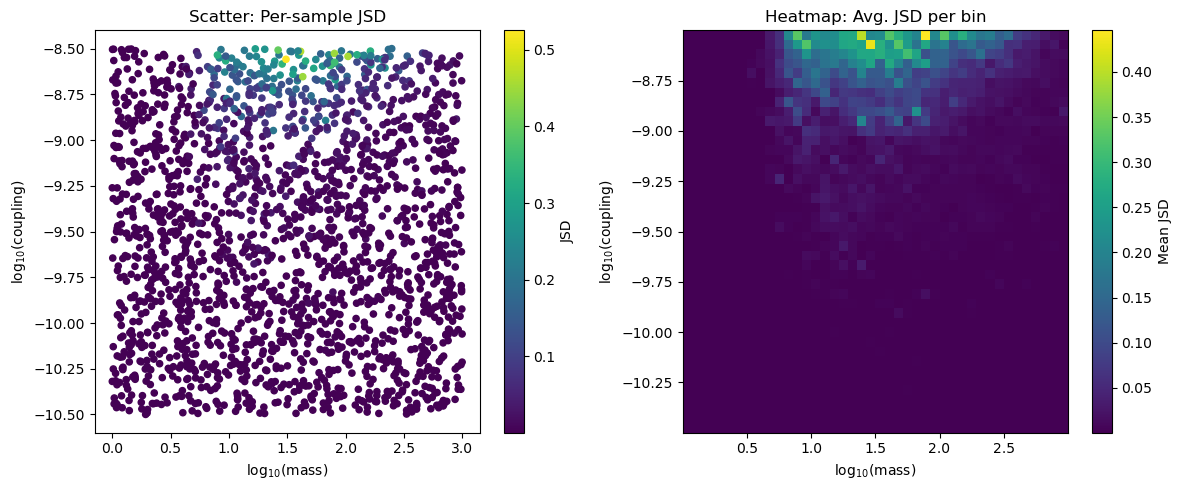

In [15]:
print("Mean JSD:", mean_jsd)
plot_jsd_diagnostics(results, bins=42, fill_holes=True)